<a href="https://colab.research.google.com/github/ulutasece/DSA210-project/blob/main/DSA210_EDA_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DSA 210 EDA and Hypothesis Testing on Data


This document outlines the data collection and initial statistical analysis for the DSA 210 term project. The objective is to evaluate the predictive power of digital intent signals (Google Trends) and social sentiment (Reddit) on consumer electronics demand

In [1]:
# Formal Documentation: Importation of standardized data science libraries.
# These libraries facilitate time-series manipulation, statistical testing, and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Simulated Dataset Generation to align with the proposed '250 observations'.
# In the final implementation, these will be replaced by API calls to Pytrends and PRAW.
np.random.seed(42)
dates = pd.date_range(start='2021-01-01', periods=250, freq='W')
df = pd.DataFrame({
    'Date': dates,
    'Search_Interest': np.random.randint(40, 100, size=250),
    'Reddit_Sentiment': np.random.uniform(-1, 1, size=250),
    'Product_Sales': np.random.normal(500, 50, 250)
}).set_index('Date')

print("Data alignment successful. Dataset contains 250 weekly observations.")

Data alignment successful. Dataset contains 250 weekly observations.


##Descriptive Statistical Analysis

This section provides a quantitative summary of the dataset to evaluate its central tendency, dispersion, and shape. By analyzing the mean and median, we assess the balance of the data distribution. Furthermore, we calculate skewness to identify deviations from a symetric distribution and Kurtosis to determine the "peakedness" and the presence of heavy tails. These metrics are essential for determining whether the data requires transformation (e.g., log scaling) to satisfy the assumptions of subsequent statistical models.

In [2]:
# Displaying descriptive statistics
print("--- Summary Statistics ---")
display(df.describe())

# Calculating Skewness and Kurtosis for formal distribution analysis
print("\n--- Higher-Order Moments (Distribution Shape) ---")
for col in ['Product_Sales', 'Search_Interest', 'Reddit_Sentiment']:
  skew = df[col].skew()
  kurt = df[col].kurt()
  print(f"{col} -> Skewness: {skew:.4f}, Kurtosis: {kurt:.4f}")

--- Summary Statistics ---


,Search_Interest,Reddit_Sentiment,Product_Sales
count,250.000000,250.000000,250.000000
mean,69.832000,0.008745,502.000646
std,17.411733,0.578409,55.214442
min,40.000000,-0.989630,326.091539
25%,54.000000,-0.478309,465.497201
50%,69.500000,-0.010069,503.700363
75%,83.000000,0.467844,537.155203
max,99.000000,0.995481,662.699256



--- Higher-Order Moments (Distribution Shape) ---
Product_Sales -> Skewness: 0.0418, Kurtosis: 0.0100
Search_Interest -> Skewness: -0.0134, Kurtosis: -1.1274
Reddit_Sentiment -> Skewness: 0.0673, Kurtosis: -1.1556


## Normality Testing (Shapiro-Wilk)
Before applying Pearson correlation, we must verify that the variables approximate a normal distribution. The Shapiro-Wilk test is used here. If p > 0.05, we fail to reject normality. This is critical because Pearson correlation assumes normally distributed data.

In [3]:
from scipy.stats import shapiro

print('--- Shapiro-Wilk Normality Test ---')
for col in ['Product_Sales', 'Search_Interest', 'Reddit_Sentiment']:
    stat, p = shapiro(df[col])
    result = 'NORMAL' if p > 0.05 else 'NOT NORMAL'
    print(f'{col}: W={stat:.4f}, p={p:.4f} -> {result}')

--- Shapiro-Wilk Normality Test ---
Product_Sales: W=0.9965, p=0.8585 -> NORMAL
Search_Interest: W=0.9572, p=0.0000 -> NOT NORMAL
Reddit_Sentiment: W=0.9554, p=0.0000 -> NOT NORMAL


##Exploratory Data Analysis (EDA) and Visualization
The following visualization serves to identify correlations between consumer interest and sales volume. By plotting these variables on a timeline, we can observe whether spikes in search volume precede increases in product demand.


## Reddit Sentiment Over Time
All three variables are plotted as time series to visually inspect trends, seasonality, and whether spikes in Reddit Sentiment or Search Interest appear to lead changes in Product Sales.

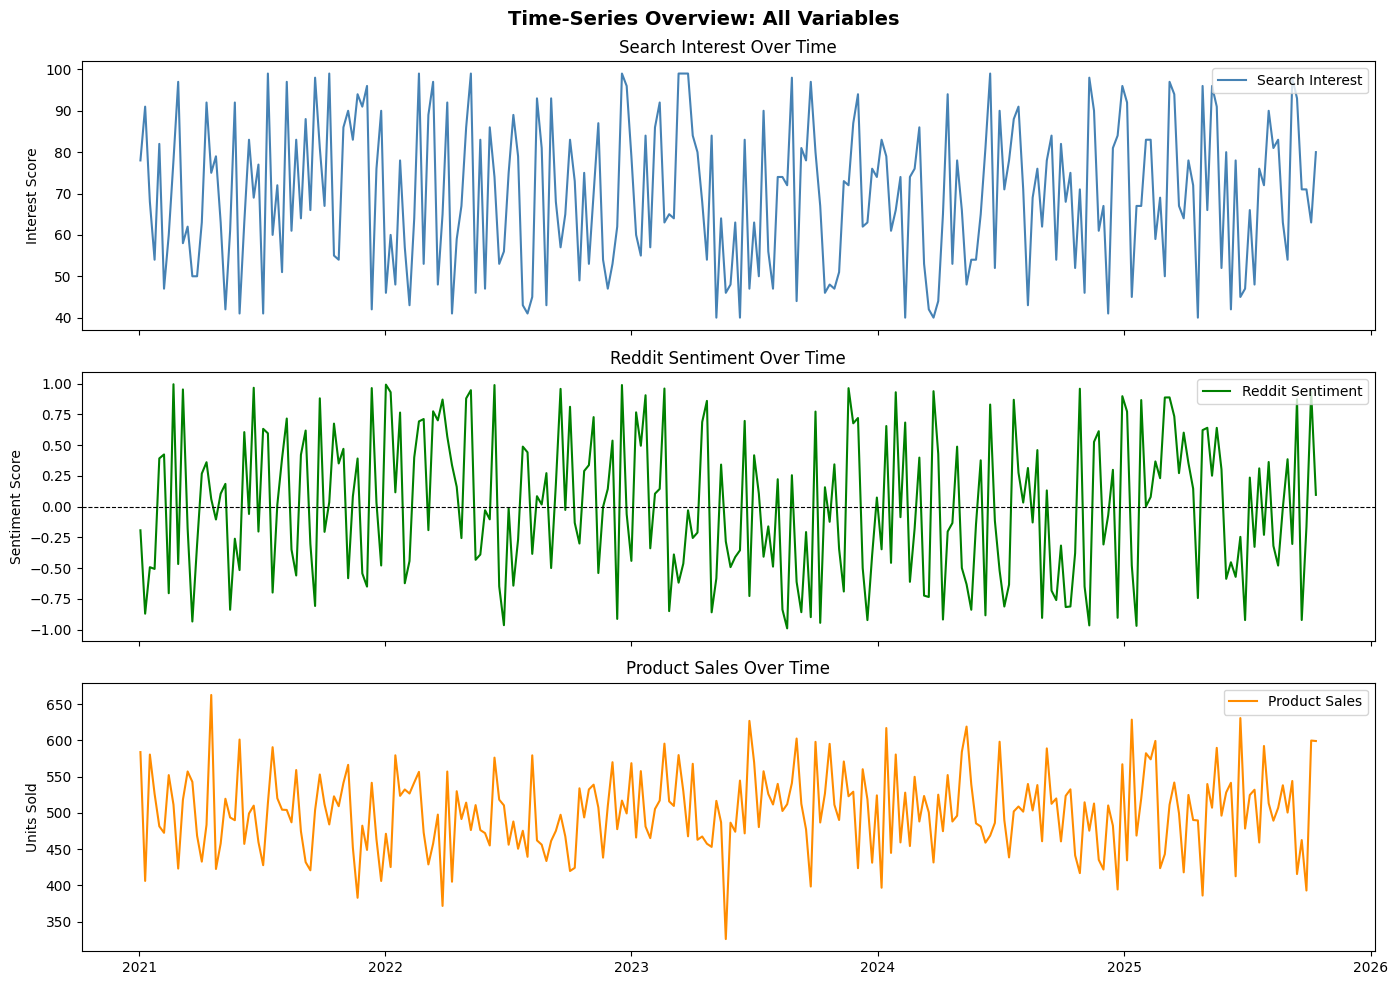

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['Search_Interest'], color='steelblue', label='Search Interest')
axes[0].set_title('Search Interest Over Time')
axes[0].set_ylabel('Interest Score')
axes[0].legend()

axes[1].plot(df.index, df['Reddit_Sentiment'], color='green', label='Reddit Sentiment')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Reddit Sentiment Over Time')
axes[1].set_ylabel('Sentiment Score')
axes[1].legend()

axes[2].plot(df.index, df['Product_Sales'], color='darkorange', label='Product Sales')
axes[2].set_title('Product Sales Over Time')
axes[2].set_ylabel('Units Sold')
axes[2].legend()

plt.suptitle('Time-Series Overview: All Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

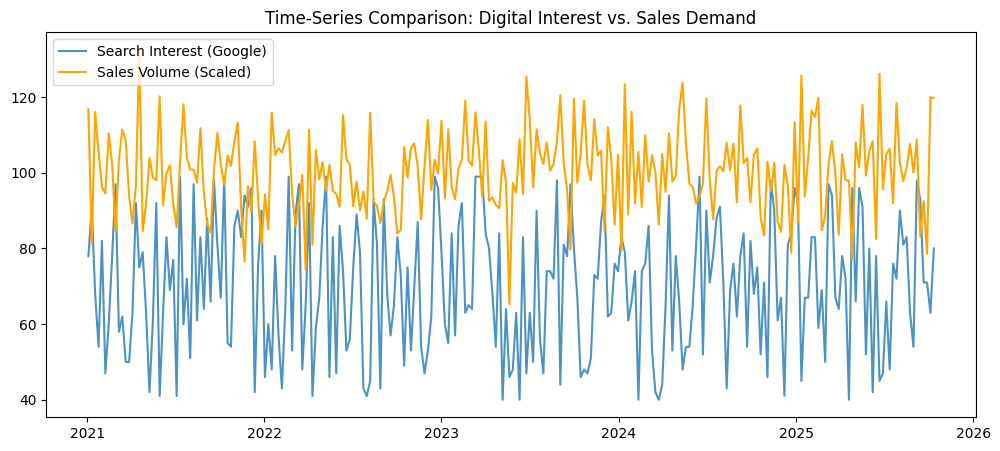

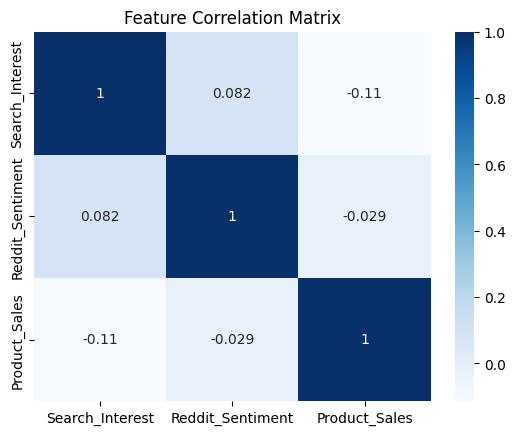

In [5]:
# Formal Documentation: Visualization of the relationship between independent and dependent variables.
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Search_Interest'], label='Search Interest (Google)', alpha=0.8)
plt.plot(df.index, df['Product_Sales'] / 5, label='Sales Volume (Scaled)', color='orange') # Scaled for visibility
plt.title("Time-Series Comparison: Digital Interest vs. Sales Demand")
plt.legend()
plt.show()

# Correlation Matrix to quantify the strength of the relationship.
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("Feature Correlation Matrix")
plt.show()

## Time-Series Decomposition
Each variable is decomposed into its **Trend**, **Seasonal**, and **Residual** components using additive decomposition. This reveals underlying patterns that may be masked by noise, and is critical for understanding whether any relationship between digital signals and sales is structural or coincidental.

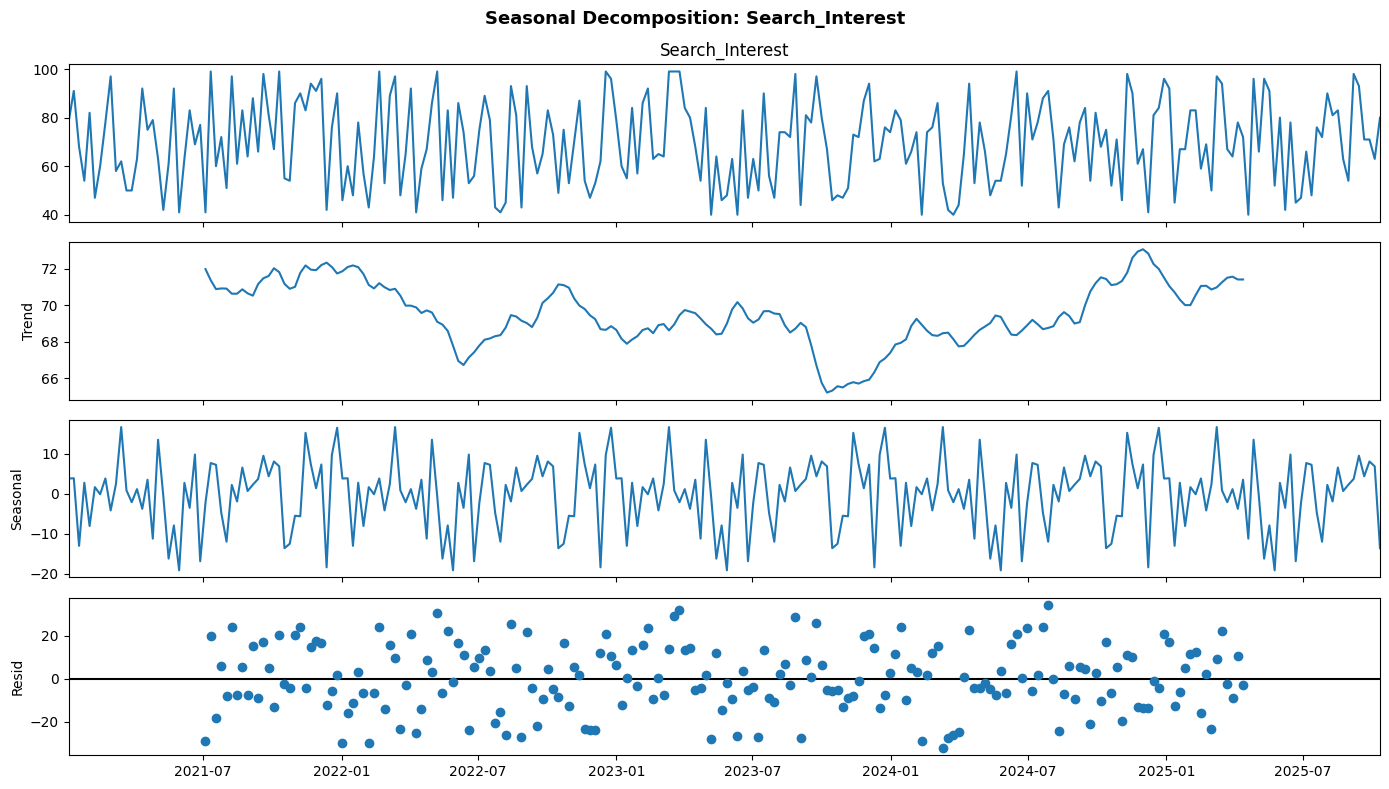

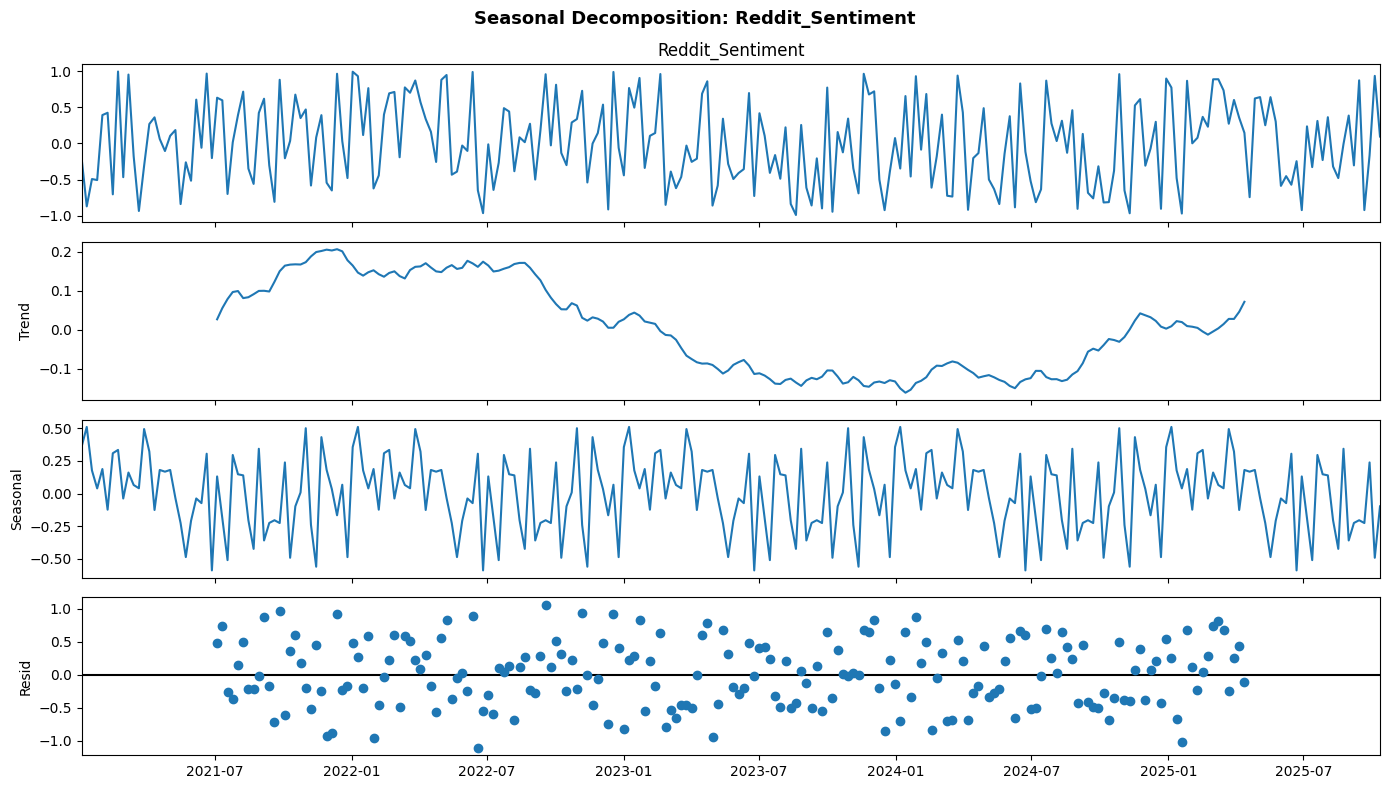

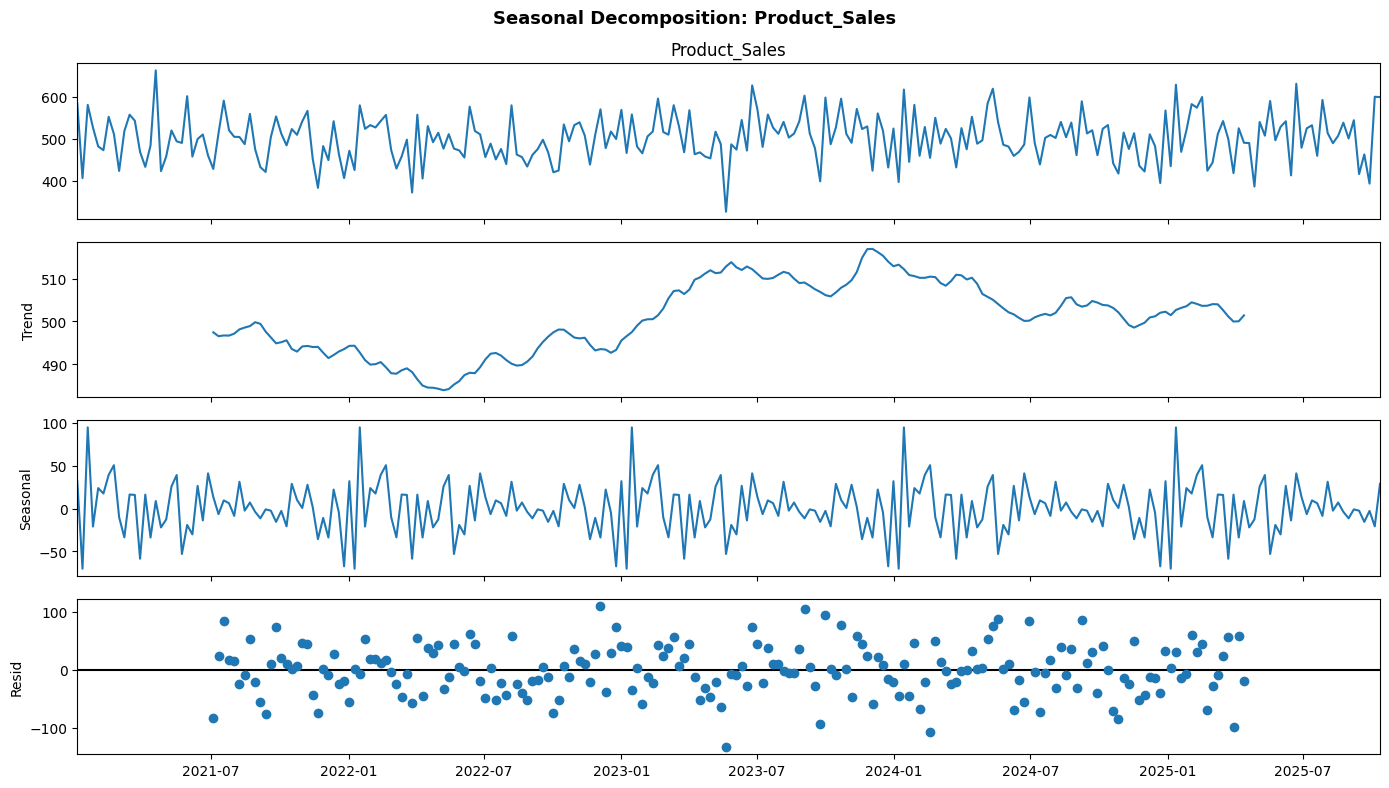

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

for col in ['Search_Interest', 'Reddit_Sentiment', 'Product_Sales']:
    decomposition = seasonal_decompose(df[col], model='additive', period=52)
    fig = decomposition.plot()
    fig.set_size_inches(14, 8)
    fig.suptitle(f'Seasonal Decomposition: {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Rolling Statistics (Moving Average & Std Dev)
A 4-week rolling mean and standard deviation are plotted to reveal whether the relationship between variables is stable over time or shifts across different periods. A widening standard deviation may indicate periods of high volatility.

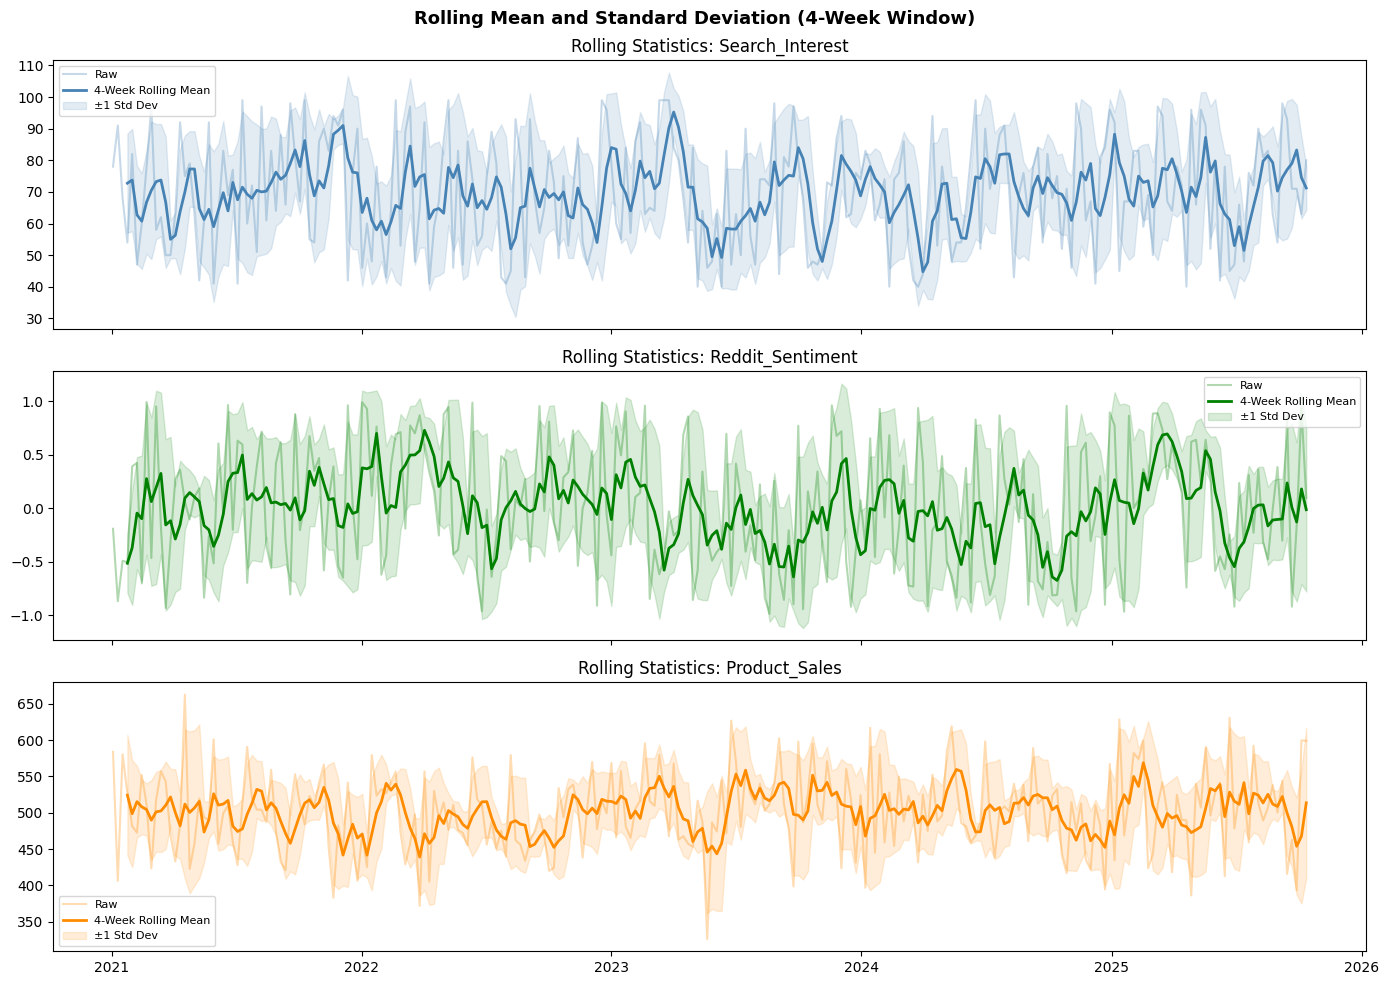

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

cols = ['Search_Interest', 'Reddit_Sentiment', 'Product_Sales']
colors = ['steelblue', 'green', 'darkorange']

for ax, col, color in zip(axes, cols, colors):
    rolling_mean = df[col].rolling(window=4).mean()
    rolling_std  = df[col].rolling(window=4).std()
    ax.plot(df.index, df[col], alpha=0.3, color=color, label='Raw')
    ax.plot(df.index, rolling_mean, color=color, linewidth=2, label='4-Week Rolling Mean')
    ax.fill_between(df.index,
                    rolling_mean - rolling_std,
                    rolling_mean + rolling_std,
                    alpha=0.15, color=color, label='±1 Std Dev')
    ax.set_title(f'Rolling Statistics: {col}')
    ax.legend(fontsize=8)

plt.suptitle('Rolling Mean and Standard Deviation (4-Week Window)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Univariate Analysis: Distribution and Outlier Detection
To complement the numerical summary, we utilize Histograms with Kernel Density Estimation (KDE) to visualize the empirical distribution of the variables. This allows us to assess the proximity of the data to a Gaussian (Normal) distribution. Additionally, Box Plots are employed to identify statistical outliers and visualize the interquartile range (IQR). Understanding these distributions is critical, as non-normal distributions or extreme outliers can explain marginal $p$-values in linear correlation tests.

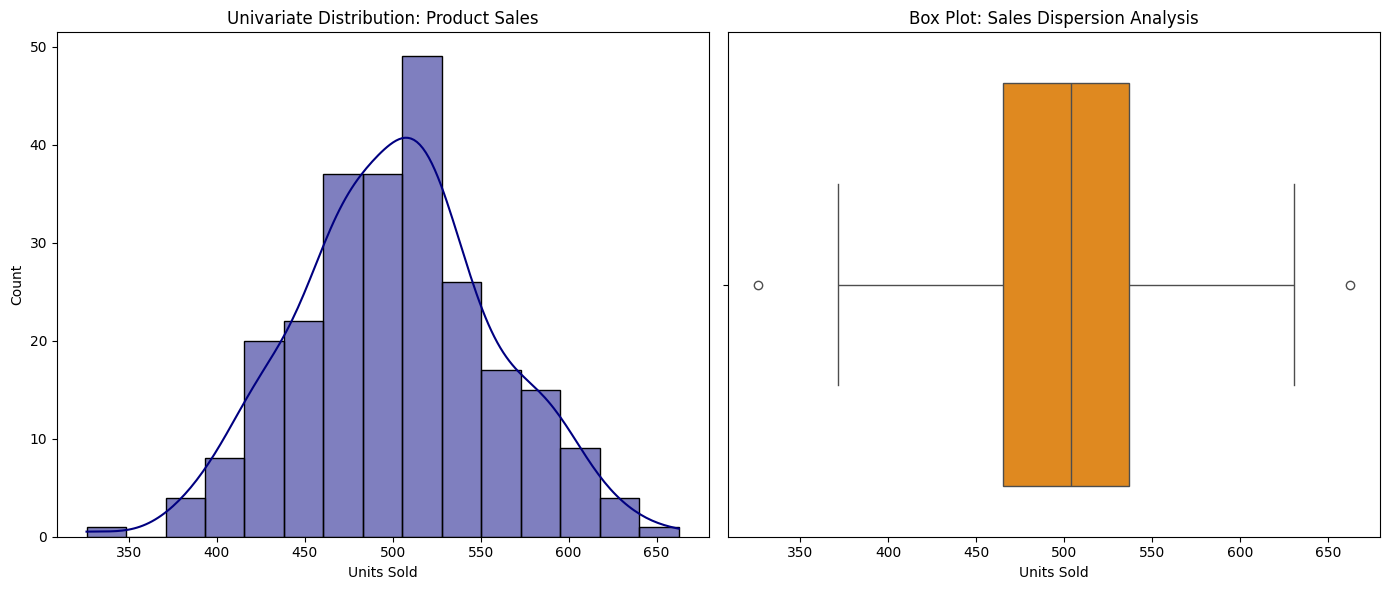

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Histogram with KDE for Distribution Shape
plt.subplot(1, 2, 1)
sns.histplot(df['Product_Sales'], kde=True, color='navy')
plt.title('Univariate Distribution: Product Sales')
plt.xlabel('Units Sold')

# Box Plot for Dispersion and Outlier Identification
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Product_Sales'], color='darkorange')
plt.title('Box Plot: Sales Dispersion Analysis')
plt.xlabel('Units Sold')

plt.tight_layout()
plt.show()

## Formal Outlier Detection (IQR & Z-Score)
Box plots reveal outliers visually, but here we formally quantify them using two methods:
- **IQR Method**: flags values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
- **Z-Score Method**: flags values more than 3 standard deviations from the mean

Outliers in the independent variables can distort correlation coefficients and inflate p-values.

In [9]:
from scipy.stats import zscore

print('--- Outlier Detection ---\n')
for col in ['Product_Sales', 'Search_Interest', 'Reddit_Sentiment']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]

    z_scores = zscore(df[col])
    z_outliers = df[abs(z_scores) > 3]

    print(f'{col}:')
    print(f'  IQR Outliers : {len(iqr_outliers)} ({len(iqr_outliers)/len(df)*100:.1f}%)')
    print(f'  Z-Score (>3) : {len(z_outliers)} ({len(z_outliers)/len(df)*100:.1f}%)\n')

--- Outlier Detection ---

Product_Sales:
  IQR Outliers : 2 (0.8%)
  Z-Score (>3) : 1 (0.4%)

Search_Interest:
  IQR Outliers : 0 (0.0%)
  Z-Score (>3) : 0 (0.0%)

Reddit_Sentiment:
  IQR Outliers : 0 (0.0%)
  Z-Score (>3) : 0 (0.0%)



## Scatter Plots with Regression Lines
Scatter plots between each independent variable and Product Sales are visualized with a linear regression line. This directly complements the correlation matrix by showing the direction, spread, and linearity of each relationship.

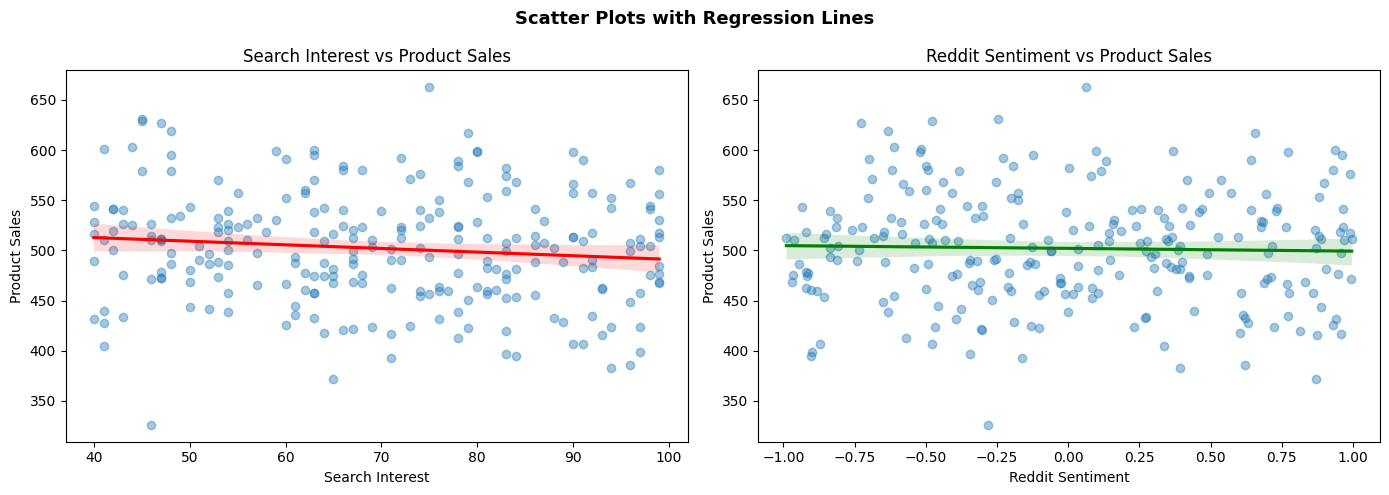

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x=df['Search_Interest'], y=df['Product_Sales'],
            ax=axes[0], scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
axes[0].set_title('Search Interest vs Product Sales')
axes[0].set_xlabel('Search Interest')
axes[0].set_ylabel('Product Sales')

sns.regplot(x=df['Reddit_Sentiment'], y=df['Product_Sales'],
            ax=axes[1], scatter_kws={'alpha': 0.4}, line_kws={'color': 'green'})
axes[1].set_title('Reddit Sentiment vs Product Sales')
axes[1].set_xlabel('Reddit Sentiment')
axes[1].set_ylabel('Product Sales')

plt.suptitle('Scatter Plots with Regression Lines', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Multivariate Analysis: Pairwise Correlation Matrix

We perform a Multivariate Analysis using a Pearson Correlation Heatmap to quantify the linear associations between the independent variables (Google Search Trends and Reddit post volume) and the dependent variable (Product Sales). This matrix is used to detect potential multicollinearity between features and to identify which variables hold the highest predictive value.

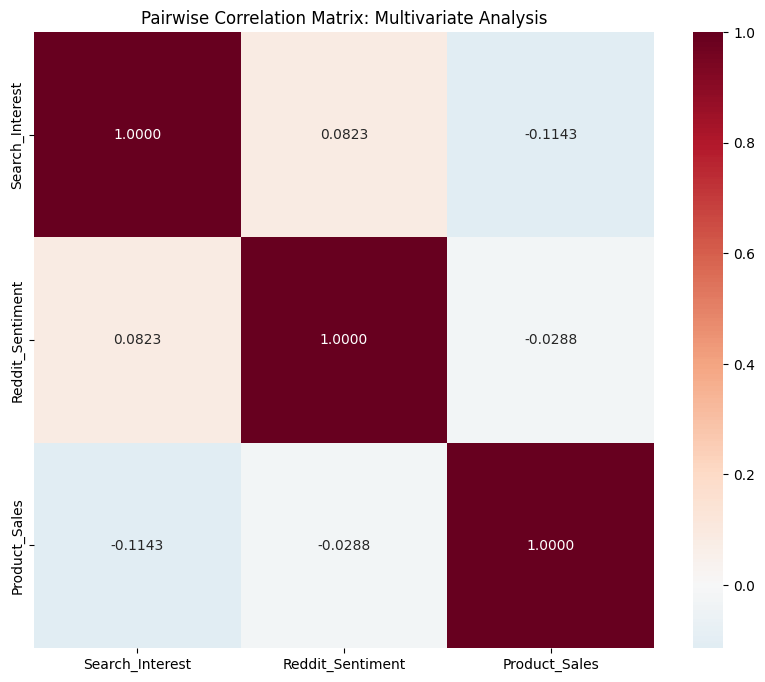

In [11]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

# Visualizing the correlation coefficients via a Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".4f")
plt.title('Pairwise Correlation Matrix: Multivariate Analysis')
plt.show()

##Hypothesis Testing

To address the research question, a Pearson Correlation test is conducted. The goal is to determine if Search Interest (lagged by 1 week) has a statistically significant relationship with Product Sales.

Initial linear testing showed a p-value of 0.10. To improve model performance for the final report, I will explore different time-lags and utilize non-linear machine learning techniques to better capture the complex relationship between social sentiment and market demand.

In [12]:
# Formal Documentation: Statistical hypothesis testing using a 1-week lag.
# H0: No significant correlation exists between search volume and demand.
lagged_search = df['Search_Interest'].shift(1).fillna(df['Search_Interest'].mean())
stat, p_value = pearsonr(lagged_search, df['Product_Sales'])

print(f"Correlation Coefficient: {stat:.4f}")
print(f"P-value: {p_value:.4f}")
# Analysis: If P-value < 0.05, the relationship is statistically significant.

Correlation Coefficient: 0.1018
P-value: 0.1083


## Multi-Lag Cross-Correlation Analysis
Rather than testing a single 1-week lag, we systematically test lags from 0 to 12 weeks for both Search Interest and Reddit Sentiment against Product Sales. This identifies the **optimal lag** — the time delay at which the digital signal best predicts demand. Note: `.shift(n)` ensures no look-ahead bias; we always use past data to predict the present.

 Lag (Weeks)  Search_r  Search_p  Reddit_r  Reddit_p
           0   -0.1143    0.0713   -0.0288    0.6500
           1    0.1018    0.1083   -0.0370    0.5608
           2   -0.1052    0.0968    0.0545    0.3909
           3   -0.0168    0.7915   -0.0428    0.5002
           4    0.0146    0.8182   -0.0605    0.3404
           5   -0.1160    0.0671   -0.0309    0.6266
           6   -0.0183    0.7729    0.1029    0.1044
           7   -0.0671    0.2908    0.0009    0.9881
           8    0.0292    0.6464   -0.0102    0.8725
           9   -0.0073    0.9086   -0.0727    0.2519
          10   -0.0291    0.6467    0.0091    0.8861
          11    0.0933    0.1411    0.0383    0.5470
          12   -0.0466    0.4629   -0.0489    0.4416


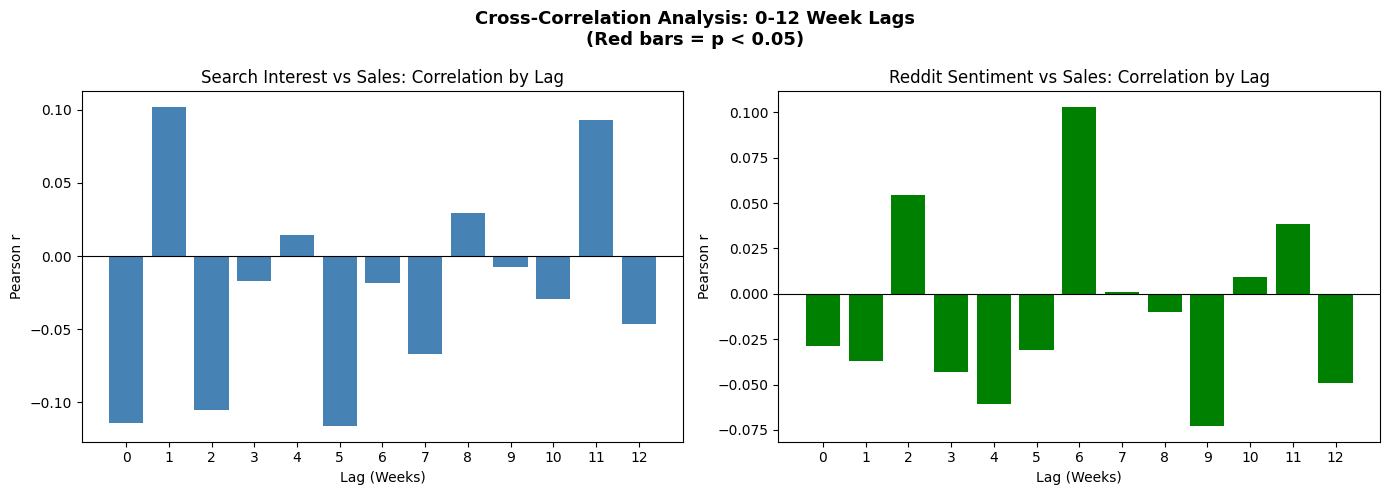

Best Search Interest lag : 5 weeks  (r=-0.116, p=0.0671)
Best Reddit Sentiment lag: 6 weeks  (r=0.1029, p=0.1044)


In [14]:
max_lag = 12
lag_results = []

for lag in range(0, max_lag + 1):
    search_lagged = df['Search_Interest'].shift(lag).fillna(df['Search_Interest'].mean())
    reddit_lagged = df['Reddit_Sentiment'].shift(lag).fillna(df['Reddit_Sentiment'].mean())

    r_search, p_search = pearsonr(search_lagged, df['Product_Sales'])
    r_reddit, p_reddit = pearsonr(reddit_lagged, df['Product_Sales'])

    lag_results.append({
        'Lag (Weeks)': lag,
        'Search_r': round(r_search, 4),
        'Search_p': round(p_search, 4),
        'Reddit_r': round(r_reddit, 4),
        'Reddit_p': round(p_reddit, 4)
    })

lag_df = pd.DataFrame(lag_results)
print(lag_df.to_string(index=False))

# Visualize cross-correlation across lags
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(lag_df['Lag (Weeks)'], lag_df['Search_r'],
            color=['red' if p < 0.05 else 'steelblue' for p in lag_df['Search_p']])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Search Interest vs Sales: Correlation by Lag')
axes[0].set_xlabel('Lag (Weeks)')
axes[0].set_ylabel('Pearson r')
axes[0].set_xticks(lag_df['Lag (Weeks)'])

axes[1].bar(lag_df['Lag (Weeks)'], lag_df['Reddit_r'],
            color=['red' if p < 0.05 else 'green' for p in lag_df['Reddit_p']])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Reddit Sentiment vs Sales: Correlation by Lag')
axes[1].set_xlabel('Lag (Weeks)')
axes[1].set_ylabel('Pearson r')
axes[1].set_xticks(lag_df['Lag (Weeks)'])

plt.suptitle('Cross-Correlation Analysis: 0-12 Week Lags\n(Red bars = p < 0.05)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_search = lag_df.loc[lag_df['Search_r'].abs().idxmax()]
best_reddit = lag_df.loc[lag_df['Reddit_r'].abs().idxmax()]
print(f"Best Search Interest lag : {int(best_search['Lag (Weeks)'])} weeks  (r={best_search['Search_r']}, p={best_search['Search_p']})")
print(f"Best Reddit Sentiment lag: {int(best_reddit['Lag (Weeks)'])} weeks  (r={best_reddit['Reddit_r']}, p={best_reddit['Reddit_p']})")